# Simulation 2: residual-aware matching

This experiment asks what happens when every observation belongs to one deliberately broad reference component. Component-only BMTS is then identically zero. The residual-aware extension restores within-component position by comparing standardized residuals.

The example is deterministic and has no fitted labels. Its one-component case also provides a direct check of the general linear program.


In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "bmts.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bmts

bmts.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = False
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")


Public root located. PAPER_SCALE=False


In [2]:
from matplotlib.patches import Ellipse

rng = np.random.default_rng(2407)
n_per_subgroup = 40
subgroup_means = np.array([[-1.4, 0.0], [1.4, 0.0]])
subgroup_sd = np.array([0.25, 0.25])
X = np.vstack([
    rng.normal(subgroup_means[0], subgroup_sd, size=(n_per_subgroup, 2)),
    rng.normal(subgroup_means[1], subgroup_sd, size=(n_per_subgroup, 2)),
])
labels = np.repeat([0, 1], n_per_subgroup)
order = np.lexsort((X[:, 0], labels))
X, labels = X[order], labels[order]

reference_covariance = np.diag([2.0**2, 0.5**2])
reference_mean = X.mean(axis=0)
inverse_square_root = np.diag(1.0 / np.sqrt(np.diag(reference_covariance)))
standardized_residuals = (X - reference_mean) @ inverse_square_root.T

responsibilities = np.ones((len(X), 1))
ground_cost = np.zeros((1, 1))
component_only = bmts.bmts_matrix(responsibilities, ground_cost)
residual_aware = np.linalg.norm(
    standardized_residuals[:, None, :] - standardized_residuals[None, :, :],
    axis=2,
)
lp_value = bmts.residual_aware_bmts(
    responsibilities[0], responsibilities[-1], ground_cost,
    standardized_residuals[0, None, :], standardized_residuals[-1, None, :], 1.0,
)

upper = np.triu_indices(len(X), k=1)
within = labels[upper[0]] == labels[upper[1]]
between = ~within
summary = pd.DataFrame(
    {
        "pair category": ["Within subgroup", "Between subgroups"],
        "component-only mean": [component_only[upper][within].mean(), component_only[upper][between].mean()],
        "residual-aware mean": [residual_aware[upper][within].mean(), residual_aware[upper][between].mean()],
        "residual-aware SD": [residual_aware[upper][within].std(), residual_aware[upper][between].std()],
    }
)
print(f"K=1 LP versus closed-form absolute error: {abs(lp_value - residual_aware[0, -1]):.3e}")
display(summary.round(3))
paper_study = paper["study2"]
pd.DataFrame({
    "paper-scale category": ["Within subgroup", "Between subgroups"],
    "component-only mean": [paper_study["component_only_within_mean"], paper_study["component_only_between_mean"]],
    "residual-aware mean": [paper_study["residual_within_mean"], paper_study["residual_between_mean"]],
    "residual-aware SD": [paper_study["residual_within_sd"], paper_study["residual_between_sd"]],
}).round(3)


K=1 LP versus closed-form absolute error: 0.000e+00


,pair category,component-only mean,residual-aware mean,residual-aware SD
0,Within subgroup,0.0,0.568,0.367
1,Between subgroups,0.0,1.534,0.214


,paper-scale category,component-only mean,residual-aware mean,residual-aware SD
0,Within subgroup,0.0,0.568,0.367
1,Between subgroups,0.0,1.534,0.214


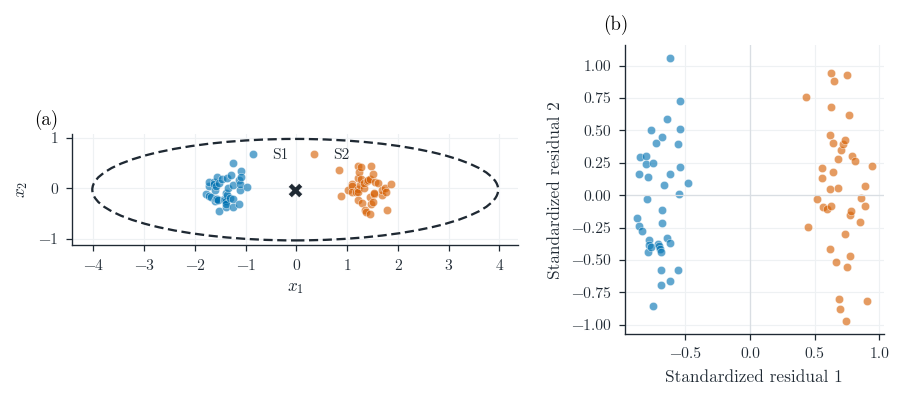

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.55), constrained_layout=True)
for group, color, name in [(0, bmts.BLUE, "S1"), (1, bmts.VERMILLION, "S2")]:
    mask = labels == group
    axes[0].scatter(X[mask, 0], X[mask, 1], s=16, color=color, alpha=0.62, edgecolor="white", linewidth=0.3, label=name)
ellipse = Ellipse(
    reference_mean,
    width=4 * np.sqrt(reference_covariance[0, 0]),
    height=4 * np.sqrt(reference_covariance[1, 1]),
    facecolor="none", edgecolor=bmts.INK, linestyle=(0, (4, 2)), linewidth=1.1,
)
axes[0].add_patch(ellipse)
axes[0].scatter(*reference_mean, marker="X", s=50, color=bmts.INK, edgecolor="white", linewidth=0.4)
axes[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$")
axes[0].legend(loc="upper center", ncol=2)
axes[0].set_aspect("equal", adjustable="box")
bmts.finish_axes(axes[0], "both")
bmts.panel_label(axes[0], "(a)")

for group, color in [(0, bmts.BLUE), (1, bmts.VERMILLION)]:
    mask = labels == group
    axes[1].scatter(
        standardized_residuals[mask, 0], standardized_residuals[mask, 1],
        s=16, color=color, alpha=0.62, edgecolor="white", linewidth=0.3,
    )
axes[1].axhline(0, color=bmts.GRID, linewidth=0.6)
axes[1].axvline(0, color=bmts.GRID, linewidth=0.6)
axes[1].set(xlabel="Standardized residual 1", ylabel="Standardized residual 2")
axes[1].set_aspect("equal", adjustable="box")
bmts.finish_axes(axes[1], "both")
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 1.** Panel (a) shows both tight subgroups inside the same broad two-standard-deviation reference ellipse. Panel (b) shows the standardized residual coordinates used by the extension.


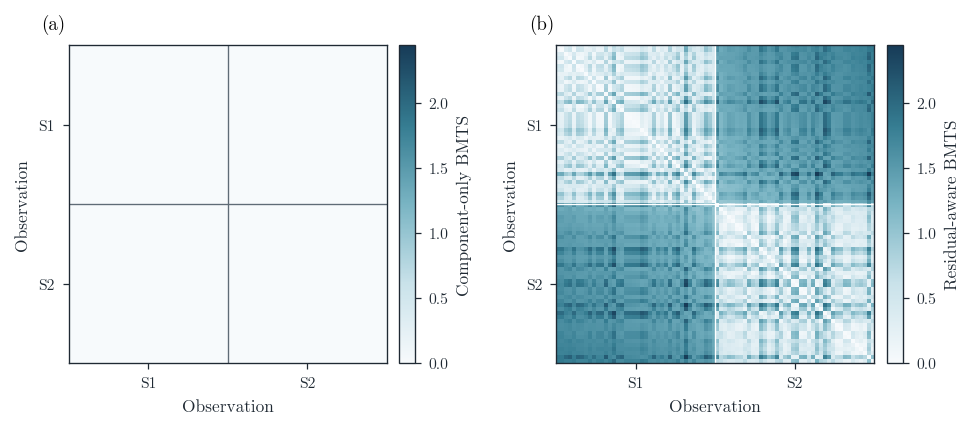

In [4]:
common_max = residual_aware.max()
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.75), constrained_layout=True)
for index, (ax, matrix, label) in enumerate([
    (axes[0], component_only, "Component-only BMTS"),
    (axes[1], residual_aware, "Residual-aware BMTS"),
]):
    image = ax.imshow(matrix, cmap=bmts.SEQUENTIAL_CMAP, vmin=0, vmax=common_max, interpolation="nearest")
    ax.axhline(n_per_subgroup - 0.5, color="white" if index else bmts.MUTED, lw=0.65)
    ax.axvline(n_per_subgroup - 0.5, color="white" if index else bmts.MUTED, lw=0.65)
    ax.set_xticks([19.5, 59.5], ["S1", "S2"])
    ax.set_yticks([19.5, 59.5], ["S1", "S2"])
    ax.set(xlabel="Observation", ylabel="Observation")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.035, label=label)
    bmts.panel_label(ax, f"({chr(97 + index)})")
plt.show()


**Figure 2.** Panel (a) is identically zero because all responsibilities equal one on the only component. Panel (b) recovers the within- and between-subgroup structure through standardized residual displacement.


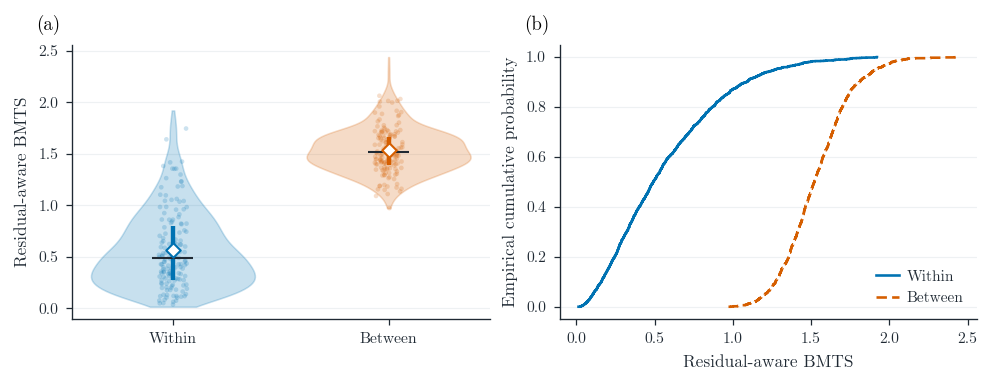

In [5]:
within_values = residual_aware[upper][within]
between_values = residual_aware[upper][between]
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.45), constrained_layout=True)
bmts.draw_violin_summary(
    axes[0], [within_values, between_values], [bmts.BLUE, bmts.VERMILLION], seed=8127,
)
axes[0].set_xticks([1, 2], ["Within", "Between"])
axes[0].set_ylabel("Residual-aware BMTS")
bmts.panel_label(axes[0], "(a)")

for values, color, label, style in [
    (within_values, bmts.BLUE, "Within", "-"),
    (between_values, bmts.VERMILLION, "Between", (0, (4, 2))),
]:
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    axes[1].step(x, y, where="post", color=color, linestyle=style, label=label)
axes[1].set(xlabel="Residual-aware BMTS", ylabel="Empirical cumulative probability")
axes[1].legend(loc="lower right")
bmts.finish_axes(axes[1], "y")
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 3.** Panel (a) summarizes the within- and between-subgroup distributions; panel (b) shows their empirical cumulative distributions. The overlap is honest: residual awareness restores local position, but it does not manufacture perfect separation.


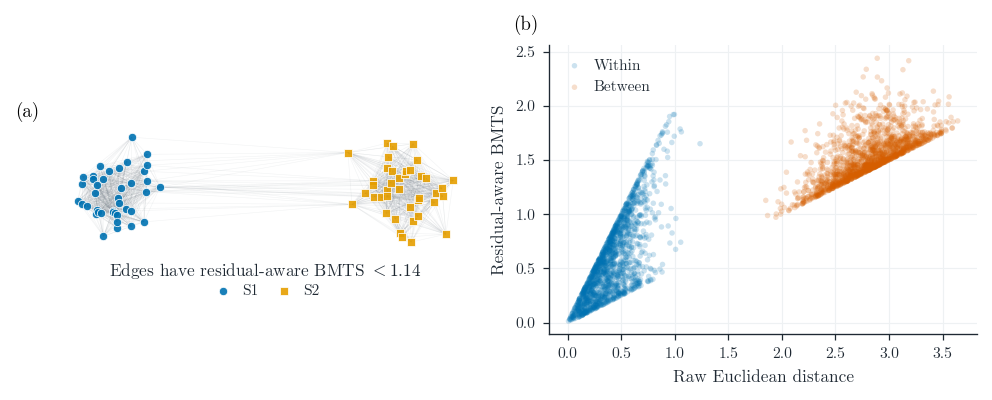

In [6]:
threshold = float((np.quantile(within_values, 0.85) + np.quantile(between_values, 0.15)) / 2)
adjacency = residual_aware < threshold
np.fill_diagonal(adjacency, False)

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.55), constrained_layout=True)
bmts.draw_relation_graph(
    axes[0], X, adjacency, groups=labels, group_names=["S1", "S2"],
    edge_alpha=0.08, node_size=16,
)
axes[0].set_xlabel(rf"Edges have residual-aware BMTS $<{threshold:.2f}$")
axes[0].legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.14))
bmts.panel_label(axes[0], "(a)")

euclidean = np.linalg.norm(X[upper[0]] - X[upper[1]], axis=1)
axes[1].scatter(
    euclidean[within], residual_aware[upper][within], s=7, color=bmts.BLUE,
    alpha=0.20, edgecolor="none", label="Within",
)
axes[1].scatter(
    euclidean[between], residual_aware[upper][between], s=7, color=bmts.VERMILLION,
    alpha=0.20, edgecolor="none", label="Between",
)
axes[1].set(xlabel="Raw Euclidean distance", ylabel="Residual-aware BMTS")
axes[1].legend(loc="upper left")
bmts.finish_axes(axes[1], "both")
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 4.** Panel (a) displays the relation induced by a transparent distance cutoff. Panel (b) shows that residual-aware BMTS is a covariance-standardized rather than raw Euclidean comparison. In this K=1 setting, the general transport program agrees with the closed form to floating-point precision.
